In [48]:
import pyreadr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1. Carga de datos

### carga del dataset

In [49]:
archivo = '../Data/listings.RData'
data_raw = pyreadr.read_r(archivo)


### Vista inicial

In [50]:
data_airbnb = data_raw['listings'].copy()

filas, columnas = data_airbnb.shape

print(data_airbnb.shape)
print(f"{filas:,} filas y {columnas} columnas" )





(171748, 80)
171,748 filas y 80 columnas


In [51]:
print("Dataset vista")
print(list(data_airbnb.columns[:10]))


display(data_airbnb.head(3))

Dataset vista
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id']


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"


# 2. Exploración de datos

### Tipos de variables

variables categóricas

In [89]:
data_airbnb['property_type'].value_counts().head()

property_type
Entire rental unit             50810
Entire home                    32898
Entire condo                   23899
Private room in rental unit    15265
Private room in home           13362
Name: count, dtype: int64

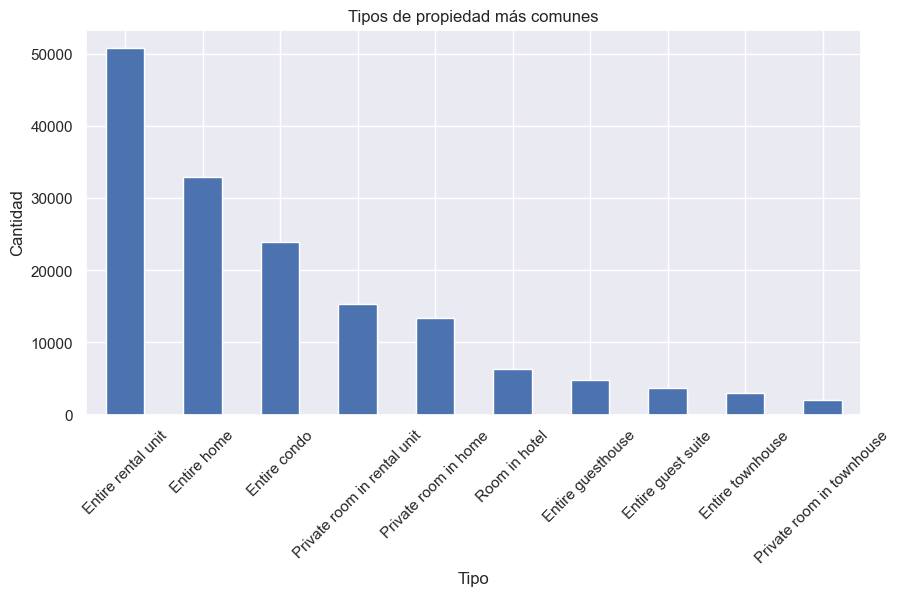

In [393]:
plt.figure(figsize=(10,5))

data_airbnb['property_type'].value_counts().head(10).plot(kind='bar')

plt.title('Tipos de propiedad más comunes')
plt.xlabel('Tipo')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

Variables numéricas

In [394]:
data_airbnb.select_dtypes(include=['number']).columns

Index(['id', 'scrape_id', 'host_id', 'latitude', 'longitude', 'accommodates',
       'bathrooms', 'minimum_nights', 'maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms', 'reviews_per_month',
       'price_clean', 'price_log'],
      dtype='str')

### Procesamiento del precio

Vista inicial de precio

In [396]:
print(data_airbnb['price'].head(7).tolist() )

['$97.00', '$160.00', '$38.00', '$145.00', '$58.00', '$49.00', '$300.00']


limpieza de precios sin símbolo

In [397]:
data_airbnb['price_clean'] = (
    data_airbnb['price']
    .str.replace('[$,]', '' , regex=True)
    .str.strip() )


data_airbnb['price_clean'] = pd.to_numeric(data_airbnb['price_clean'], errors='coerce' )

print(data_airbnb['price_clean'].head(8).tolist())

[97.0, 160.0, 38.0, 145.0, 58.0, 49.0, 300.0, 150.0]


##### Valores faltantes

limpieza de valores

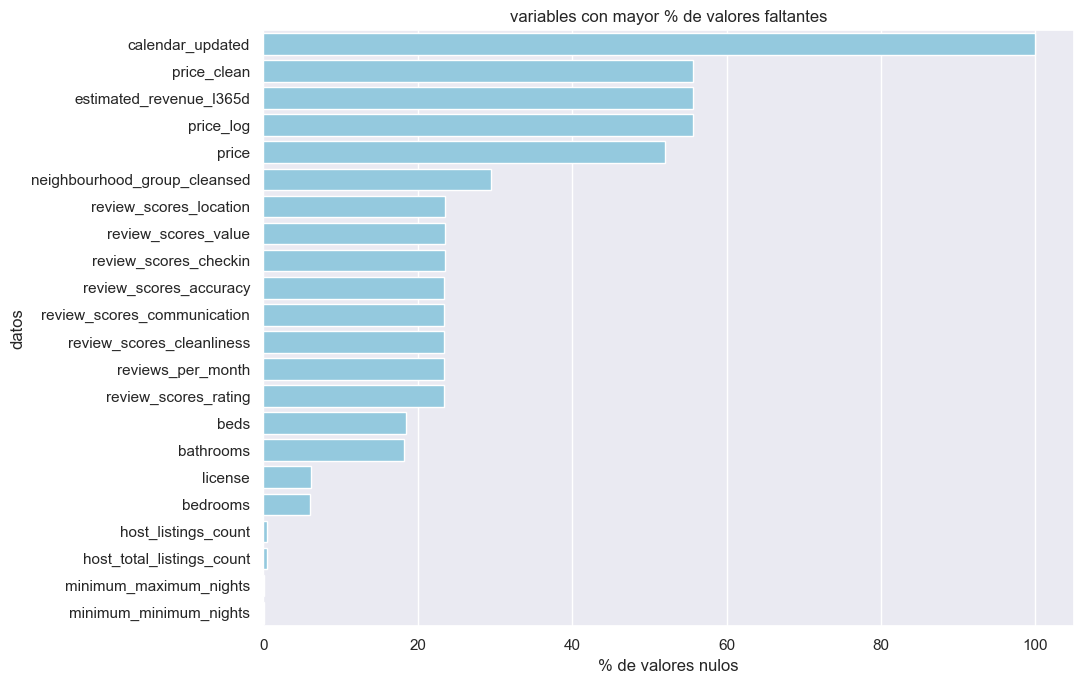

In [504]:
p_nulos = (
    data_airbnb.isnull().sum() / len(data_airbnb) *(100)
).sort_values(ascending=False)

tabla_nulos = p_nulos[p_nulos > 0].reset_index( )
tabla_nulos.columns = ['datos', 'porcentaje_nulo']

plt.figure(figsize=(11, 7))
sns.barplot(
    data=tabla_nulos.head(22), 
    x='porcentaje_nulo', y='datos',
    color='skyblue'
)

plt.title('variables con mayor % de valores faltantes')
plt.xlabel('% de valores nulos')
plt.ylabel('datos')
plt.tight_layout()
plt.show()


In [505]:
vAltos_nulos = (p_nulos > 50).sum()

print(f"Variables con más del 50% de nulos: {vAltos_nulos}")
print()

print("Primeros 10 con más % de nulos")
print(tabla_nulos.head(11))

Variables con más del 50% de nulos: 5

Primeros 10 con más % de nulos
                           datos  porcentaje_nulo
0               calendar_updated       100.000000
1                    price_clean        55.605888
2        estimated_revenue_l365d        55.605888
3                      price_log        55.605888
4                          price        52.041945
5   neighbourhood_group_cleansed        29.510096
6         review_scores_location        23.480914
7            review_scores_value        23.480914
8          review_scores_checkin        23.478585
9         review_scores_accuracy        23.471598
10   review_scores_communication        23.469269


#### Variable respuesta Price

distribución del precio

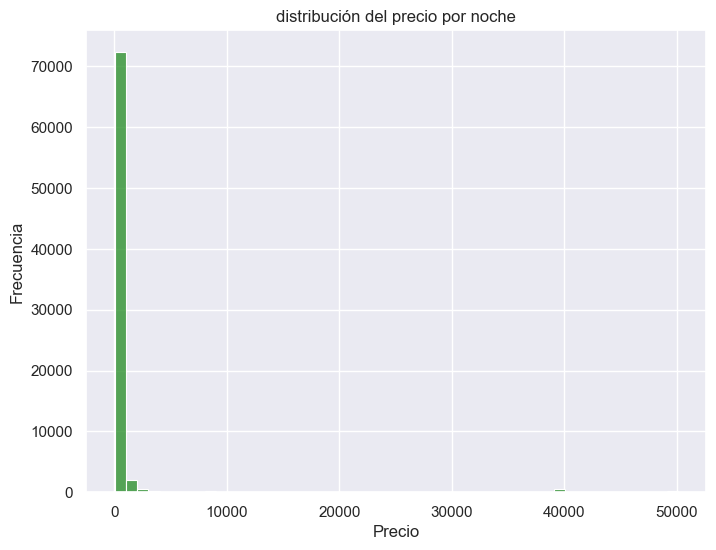

In [506]:
plt.figure(figsize=(8,6))

sns.histplot(data_airbnb['price_clean'], bins=50, color='forestgreen'  )

plt.title('distribución del precio por noche')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')


plt.show()

#### valores atípicos (outliers)

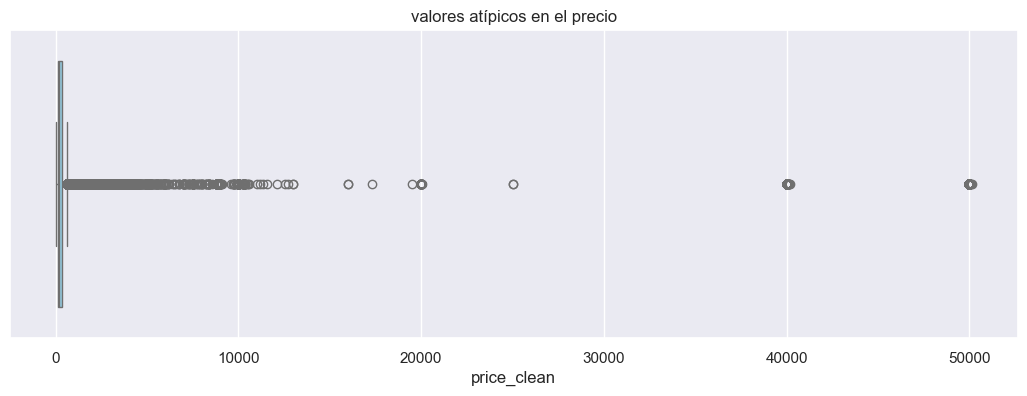

In [525]:
plt.figure(figsize=(13,4))

sns.boxplot(x=data_airbnb['price_clean'], color='skyblue' )

plt.title('valores atípicos en el precio')
plt.show()

#### cuartiles y límite superior

In [526]:
cuartil1 = data_airbnb['price_clean'].quantile(0.25)
cuartil3 = data_airbnb['price_clean'].quantile(0.75)
IQR = cuartil3 - cuartil1

limite_superior = cuartil3+ 1.5 * IQR


print(cuartil1)
print(cuartil3)
print(IQR)
print(limite_superior)

data_sin_outliers = data_airbnb[
    data_airbnb['price_clean'] <= limite_superior
]


120.0
326.0
206.0
635.0


Data sin outliers

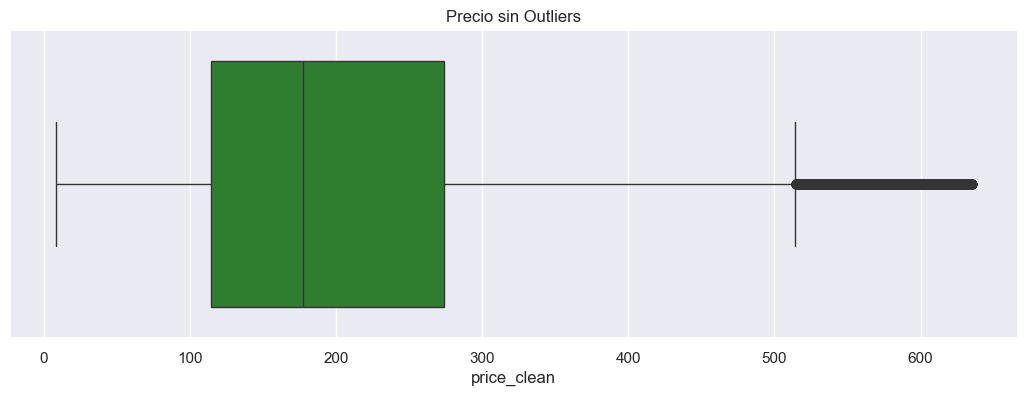

In [554]:
plt.figure(figsize=(13,4))

sns.boxplot(x=data_sin_outliers['price_clean'], color='forestgreen')

plt.title('Precio sin Outliers')
plt.show()

comparación

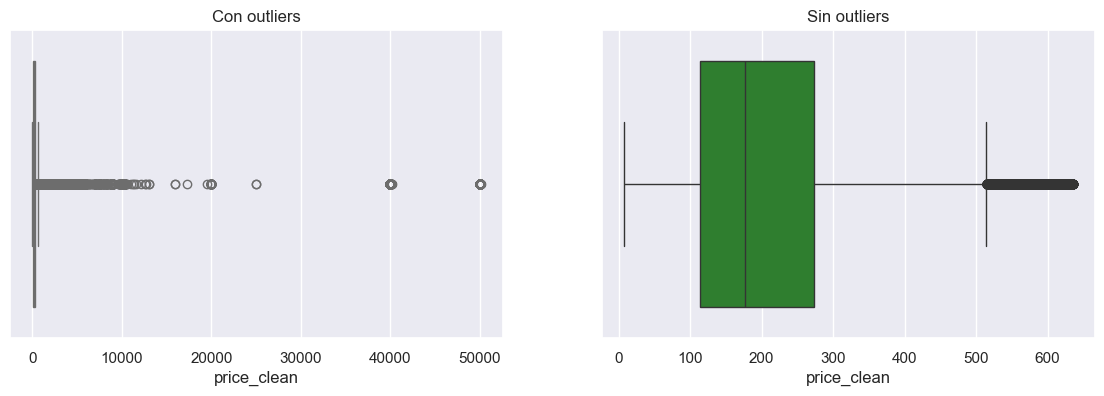

In [555]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))


sns.boxplot(x=data_airbnb['price_clean'], ax=axes[0], color='salmon')
axes[0].set_title('Con outliers')

sns.boxplot(x=data_sin_outliers['price_clean'], ax=axes[1], color='forestgreen')
axes[1].set_title('Sin outliers')

plt.show()

#### transformación logarítmica

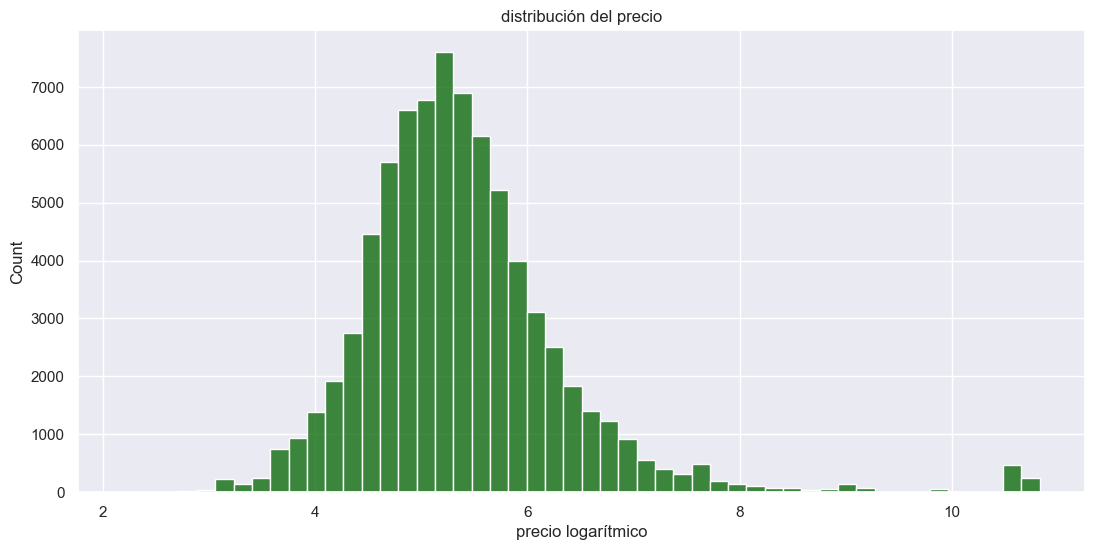

In [556]:
data_airbnb['price_log'] = np.log1p(data_airbnb['price_clean'])

plt.figure(figsize=(13,6))

sns.histplot(data_airbnb['price_log'], bins=50, color='darkgreen')

plt.title('distribución del precio')
plt.xlabel('precio logarítmico' )
plt.show()

#### precio vs variables relevantes

según tipo de habitación

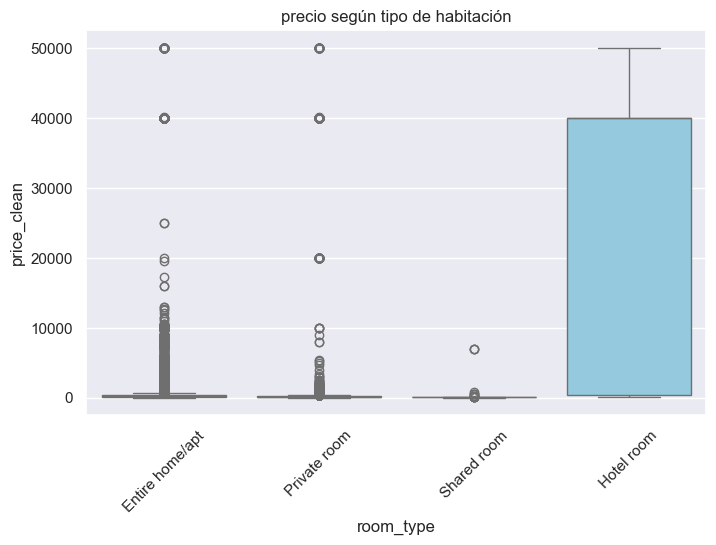

In [557]:
plt.figure(figsize=(8,5))

sns.boxplot(x='room_type', y='price_clean', data=data_airbnb, color='skyblue'  )

plt.title('precio según tipo de habitación')
plt.xticks(rotation=45)
plt.show()

precio por zona

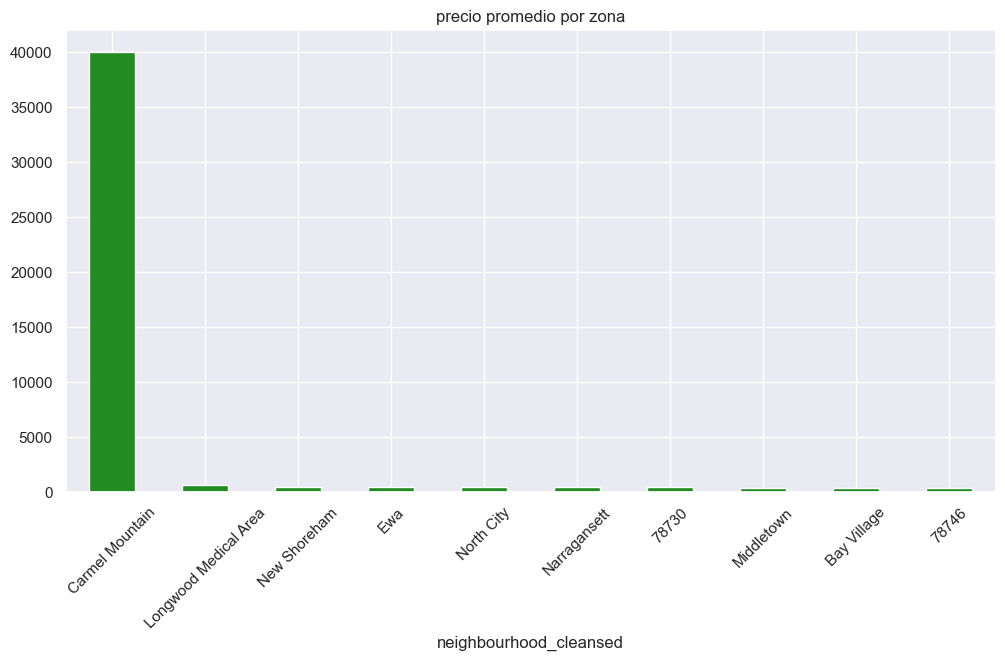

In [558]:


tp_zonas = data_airbnb.groupby('neighbourhood_cleansed')['price_clean'].median().sort_values(ascending=False).head(10)


plt.figure(figsize=(12,6))
tp_zonas.plot(kind='bar', color='forestgreen')
plt.title('precio promedio por zona')

plt.xticks(rotation=45)
plt.show()

frecuencia de zonas

In [564]:
data_airbnb['neighbourhood_cleansed'].value_counts().head(12)


neighbourhood_cleansed
Primary Urban Center    6711
Lahaina                 5254
Kihei-Makena            4459
North Kona              3721
Bedford-Stuyvesant      2613
Midtown                 2587
North Shore Kauai       2329
Williamsburg            2056
South Kohala            1942
Long Beach              1906
Mission Bay             1886
Hollywood               1758
Name: count, dtype: int64

#### matriz de correlación

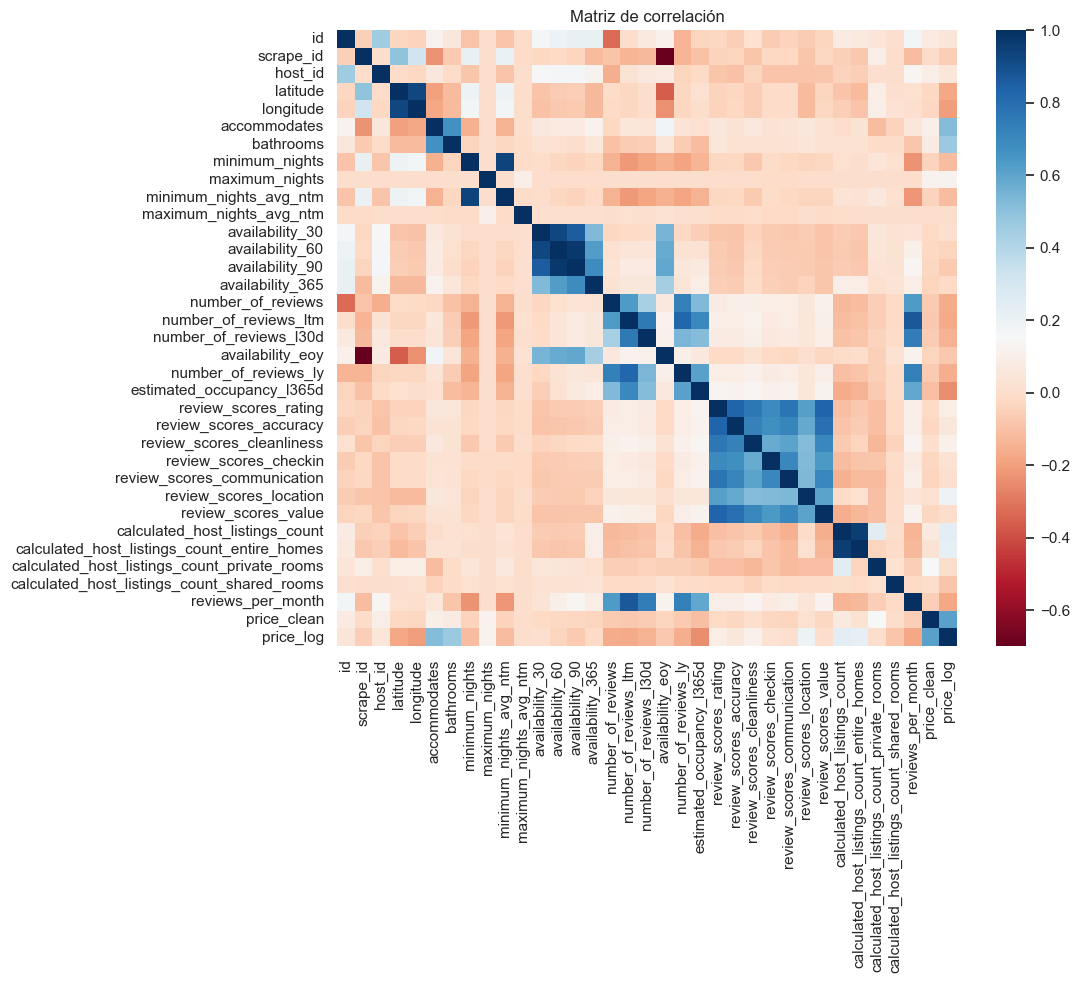

In [565]:
corr = data_airbnb.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='RdBu')
plt.title('Matriz de correlación')
plt.show()

#### selección de variables

In [566]:
features = [
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms',
    'number_of_reviews',
    'availability_365'
]

target = 'price_clean'

# 3. Análisis de grupos

In [568]:
data_airbnb.groupby('room_type')['price_clean'].mean()

room_type
Entire home/apt      505.122921
Hotel room         24477.200308
Private room         838.869637
Shared room          149.372093
Name: price_clean, dtype: float64

In [569]:
data_airbnb.groupby('property_type')['price_clean'].median().sort_values(ascending=False).head(10)

property_type
Hotel room                   40000.0
Room in resort                2929.0
Entire home/apt               2174.0
Entire villa                   625.0
Lighthouse                     552.0
Room in hotel                  388.0
Private room in resort         368.0
Houseboat                      311.0
Entire serviced apartment      307.5
Private room in island         300.0
Name: price_clean, dtype: float64

In [570]:
data_airbnb.groupby('neighbourhood_cleansed')['price_clean'].median().sort_values(ascending=False).head(10)

neighbourhood_cleansed
Carmel Mountain          40000.0
Longwood Medical Area      611.0
New Shoreham               469.0
Ewa                        461.0
North City                 454.0
Narragansett               428.0
78730                      423.0
Middletown                 403.5
Bay Village                403.0
78746                      390.0
Name: price_clean, dtype: float64